In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import torch as t
from tqdm.auto import tqdm

from forget.model import Llama3Wrapper
from forget.model.chat import Chat
from forget.model.llama.src import SignedSteer, AddSteer, GatedSteer

from evaluation import (
    add_idk_ratio_column,
    load_or_empty_results,
    make_run_specs,
    plot_effect_heatmaps,
    plot_metric_by_scale,
    run_qa_benchmark,
    sample_per_concept,
    )
from optimize import (
    load_best_scales,
    optimize_scale_for_target,
    sample_forget_retain_sets,
    sanitize_generated_text,
    trim_to_last_assistant,
    )
from vectors import (
    collect_grouped_activations,
    lda_vectors,
    plot_forget_vector_similarity,
    plot_gated_separation,
    plot_vdetect_gate,
    plot_vdetect_similarity,
    pool_activation_dict,
    )

HF_TOKEN = os.getenv("HF_TOKEN")
DATA_STORE = Path("store/concepts")
STORE = Path("store/llama3_concepts")
STORE.mkdir(parents=True, exist_ok=True)

In [3]:
llm = Llama3Wrapper(hf_token=HF_TOKEN, size="8b", use_chat=True, gpu_id=0)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

# Calculate Steering Vectors

In [4]:
def signed_steer_factory(v_detect, v_steer, device):
    def make(layer, scale):
        return SignedSteer(v_detect=v_detect[layer].to(device),
                           v_steer=v_steer[layer].to(device),
                           scale=scale)
    return make

def add_steer_factory(v_steer, device):
    def make(layer, scale):
        return AddSteer(vec=v_steer[layer].to(device), scale=scale)
    return make

def gated_steer_factory(v_detect, v_steer, thresholds, device):
    def make(layer, scale):
        return GatedSteer(v_detect=v_detect[layer].to(device),
                          v_steer=v_steer[layer].to(device),
                          tau=thresholds[layer],
                          scale=scale)
    return make

In [5]:
IDK_ANSWER = "I don't know."
QA_SYSTEM = "Answer the question concisely in one phrase or sentence."
KNOW_SYSTEM = "You are knowledgeable and answer truthfully."

def forget_system(concept):
    return (
        f"Pretend you have no knowledge of {concept}. "
        f"You cannot recall any information about {concept}. "
        "If asked, say 'I don't know.'"
    )

def true_answer(row):
    return row.answer

def idk_answer(_):
    return IDK_ANSWER

In [6]:
train_path = DATA_STORE / "train.csv"
test_path = DATA_STORE / "test.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
concepts = df_train["concept"].unique().tolist()

train_by_concept = {
    concept: df_train[df_train["concept"] == concept].reset_index(drop=True)
    for concept in concepts
}
test_by_concept = {
    concept: df_test[df_test["concept"] == concept].reset_index(drop=True)
    for concept in concepts
}

In [7]:
df_train.head(1)

,concept,subtopic,question,answer
0,lasers,Helium-neon laser facts,What property of the HeNe laser keeps its freq...,Frequency stability


In [8]:
know_path = STORE / "know_answer_acts.pt"
know_mask_path = STORE / "know_answer_masks.pt"
forget_path = STORE / "forget_answer_acts.pt"
forget_mask_path = STORE / "forget_answer_masks.pt"

if all(path.exists() for path in [know_path, know_mask_path, forget_path, forget_mask_path]):
    know_acts = t.load(know_path)
    know_masks = t.load(know_mask_path)
    forget_acts = t.load(forget_path)
    forget_masks = t.load(forget_mask_path)
else:
    know_acts, know_masks = collect_grouped_activations(
        llm,
        train_by_concept,
        chat_factory_fn=lambda concept: Chat(system_prompt=KNOW_SYSTEM if concept is not None else KNOW_SYSTEM),
        answer_fn=true_answer,
        batch_size=128,
        progress_desc="Train knowledgeable activations",
    )
    forget_acts, forget_masks = collect_grouped_activations(
        llm,
        train_by_concept,
        chat_factory_fn=lambda concept: Chat(system_prompt=forget_system(concept)),
        answer_fn=idk_answer,
        batch_size=128,
        progress_desc="Train forget activations",
    )
    t.save(know_acts, know_path)
    t.save(know_masks, know_mask_path)
    t.save(forget_acts, forget_path)
    t.save(forget_masks, forget_mask_path)

know_acts_mean = pool_activation_dict(know_acts, know_masks)
forget_acts_mean = pool_activation_dict(forget_acts, forget_masks)

Train knowledgeable activations:   0%|          | 0/10 [00:00<?, ?it/s]

Train forget activations:   0%|          | 0/10 [00:00<?, ?it/s]

In [9]:
test_acts_path = STORE / "know_answer_acts_test.pt"
test_mask_path = STORE / "know_answer_masks_test.pt"

if test_acts_path.exists() and test_mask_path.exists():
    know_acts_test = t.load(test_acts_path)
    know_masks_test = t.load(test_mask_path)
else:
    know_acts_test, know_masks_test = collect_grouped_activations(
        llm,
        test_by_concept,
        chat_factory_fn=lambda concept: Chat(system_prompt=KNOW_SYSTEM if concept is not None else KNOW_SYSTEM),
        answer_fn=true_answer,
        batch_size=128,
        progress_desc="Test knowledgeable activations",
    )
    t.save(know_acts_test, test_acts_path)
    t.save(know_masks_test, test_mask_path)

know_acts_test_mean = pool_activation_dict(know_acts_test, know_masks_test)

Test knowledgeable activations:   0%|          | 0/10 [00:00<?, ?it/s]

In [10]:
v_detect_path = STORE / "v_detect.pt"
v_forget_per_path = STORE / "v_forget_per.pt"
v_forget_path = STORE / "v_forget.pt"
thresholds_path = STORE / "thresholds.pt"

if all(path.exists() for path in [v_detect_path, v_forget_per_path, v_forget_path, thresholds_path]):
    v_detect = t.load(v_detect_path)
    v_forget_per = t.load(v_forget_per_path)
    v_forget = t.load(v_forget_path)
    thresholds = t.load(thresholds_path)
else:
    v_detect, v_forget_per, v_forget, thresholds = lda_vectors(
        know_acts,
        forget_acts,
        concepts,
        know_masks=know_masks,
        forget_masks=forget_masks,
    )
    t.save(v_detect, v_detect_path)
    t.save(v_forget_per, v_forget_per_path)
    t.save(v_forget, v_forget_path)
    t.save(thresholds, thresholds_path)

lda_vectors detect:   0%|          | 0/10 [00:00<?, ?it/s]

lda_vectors forget:   0%|          | 0/10 [00:00<?, ?it/s]

In [11]:
thresholds[concepts[0]]

tensor([0.0038, 0.0133, 0.0272, 0.0469, 0.0646, 0.0330, 0.0559, 0.0145, 0.0977,
        0.0777, 0.0552, 0.0450, 0.0803, 0.0441, 0.0195, 0.0829, 0.0587, 0.0408,
        0.1064, 0.1153, 0.1846, 0.3770, 0.3244, 0.3295, 0.4178, 0.5490, 0.7230,
        0.6801, 0.7328, 1.1117, 1.6367, 1.2538])

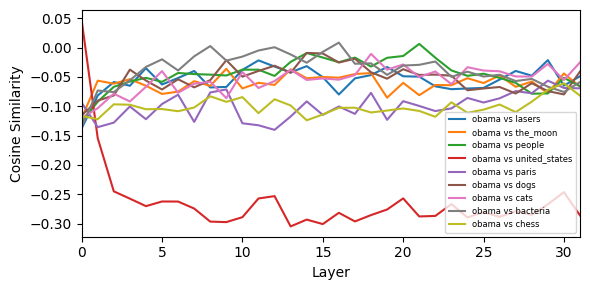

In [12]:
plot_vdetect_similarity(v_detect, concepts, target="obama")

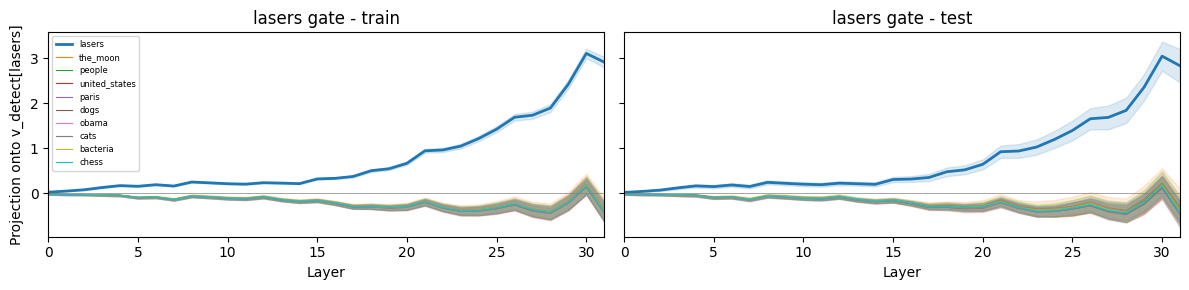

In [13]:
plot_vdetect_gate(concepts[0], concepts, know_acts_mean, know_acts_test_mean, v_detect)

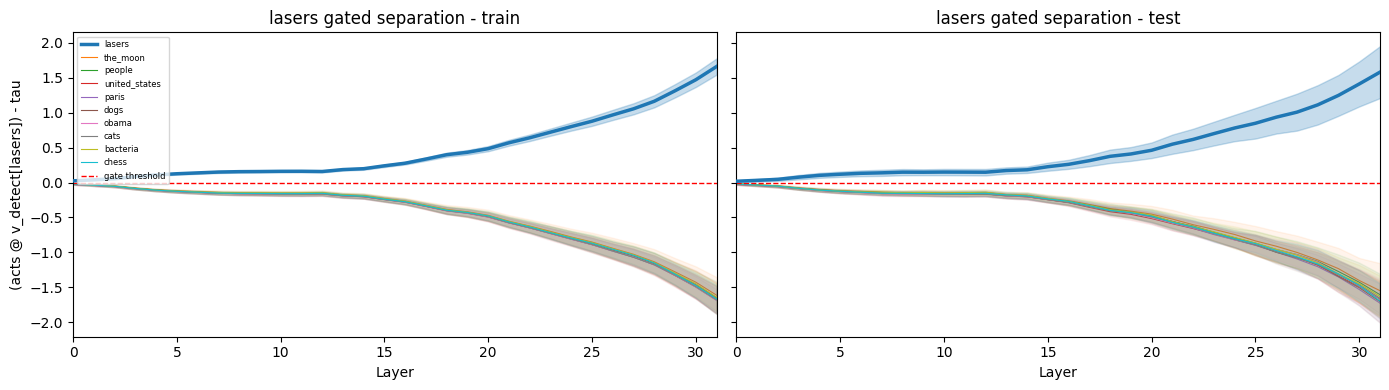

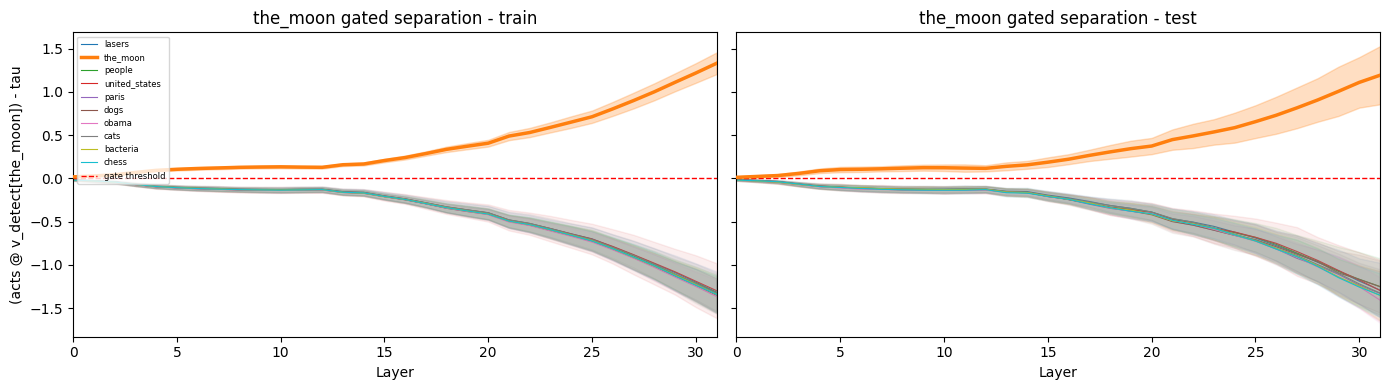

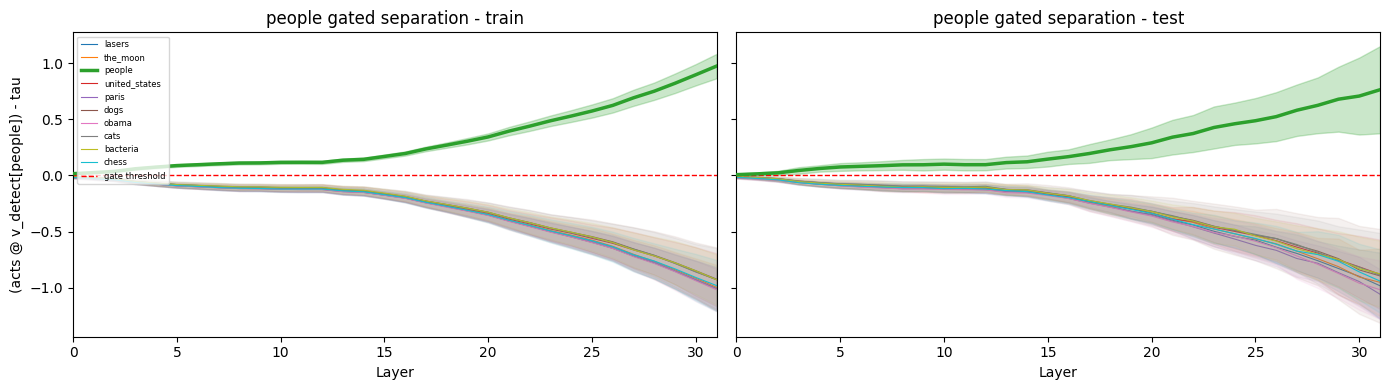

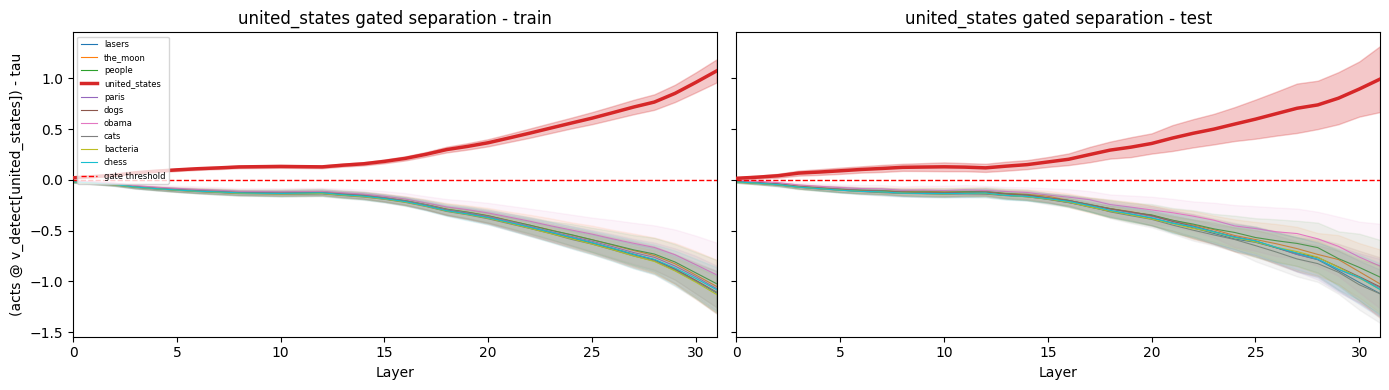

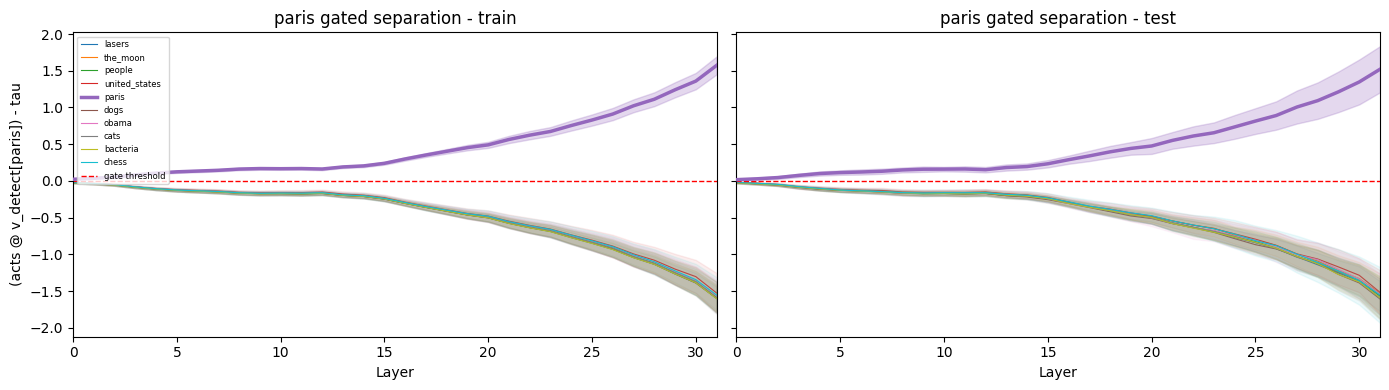

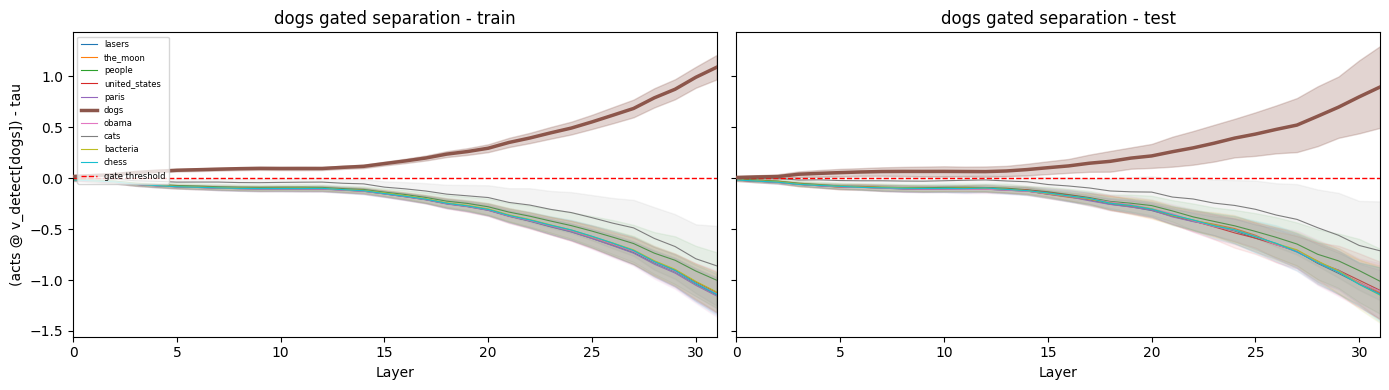

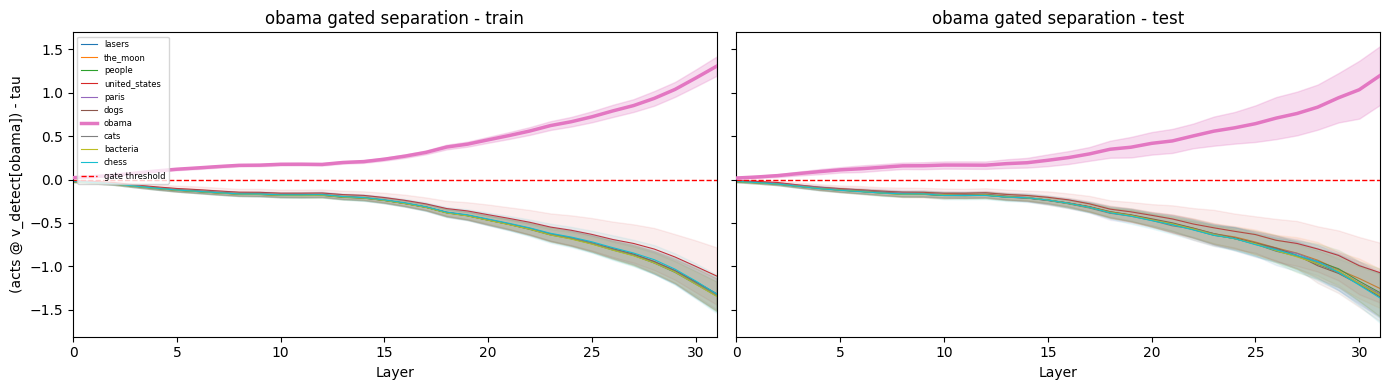

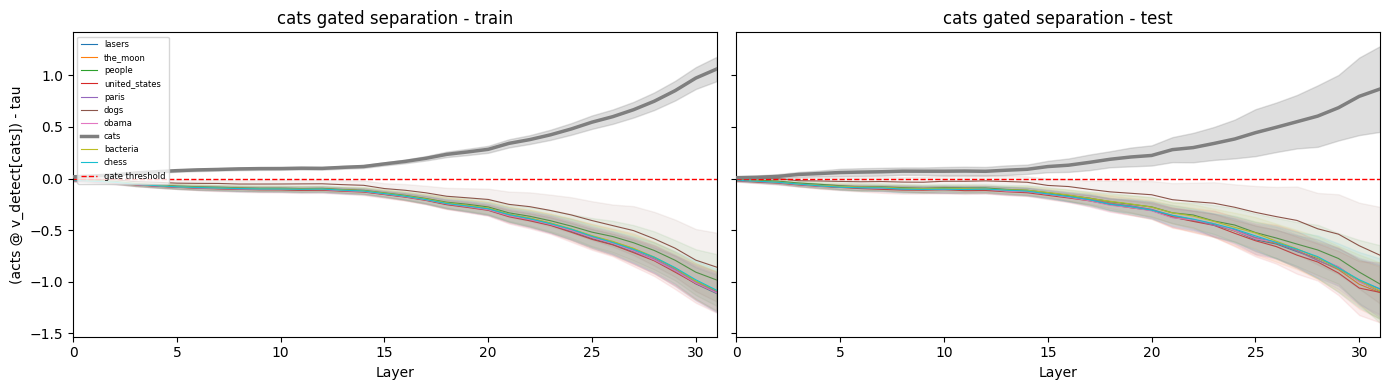

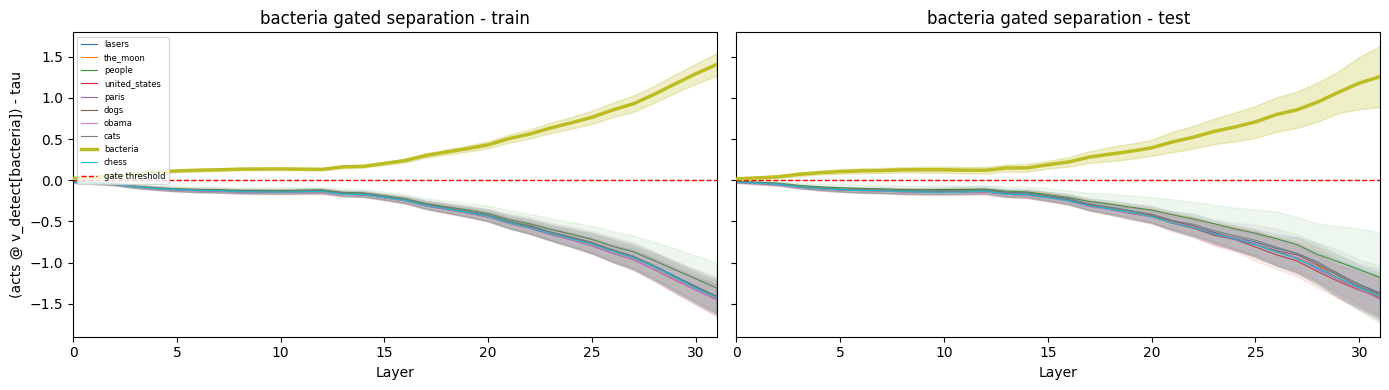

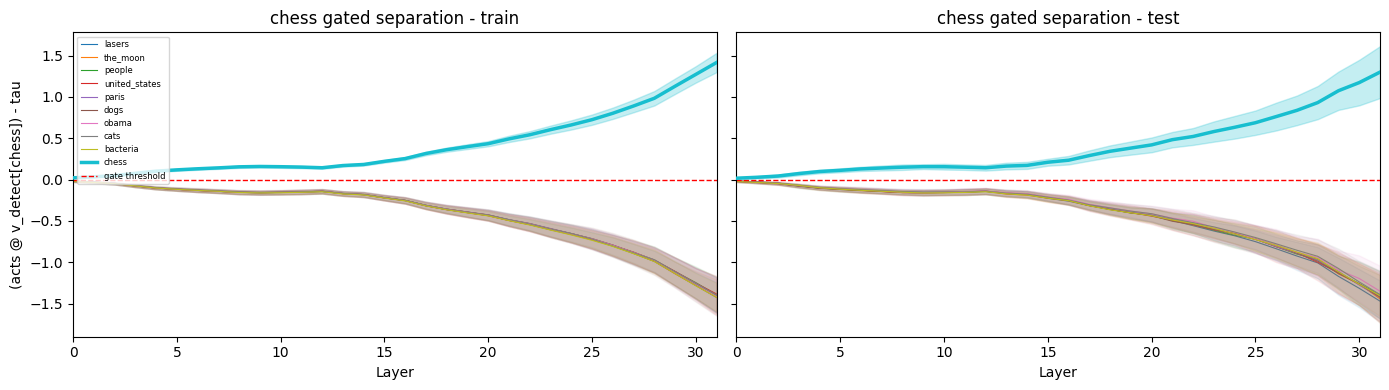

In [16]:
for target in concepts:
    plot_gated_separation(target, concepts, know_acts_mean, know_acts_test_mean, v_detect, thresholds)

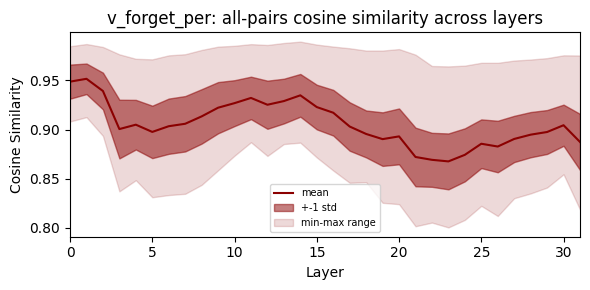

In [17]:
plot_forget_vector_similarity(v_forget_per, concepts)

# Optimizing Scale w objective

In [18]:
# Optimization helpers are imported above.

In [19]:
OBJECTIVE_LAYERS = list(range(15, 26, 3))
OBJECTIVE_RESULTS_PATH = STORE / "best_scales_rouge_idk.csv"
OBJECTIVE_STUDIES_PATH = STORE / "objective_studies.pkl"
OBJECTIVE_TRIALS_PATH = STORE / "objective_trials.pkl"

def build_objective_chat(row):
    chat = Chat(system_prompt=QA_SYSTEM)
    chat.add_user_message(row.question)
    return chat

In [20]:
objective_targets = concepts
objective_rows = []
objective_studies = {}
objective_trials = {}

for target in tqdm(objective_targets, desc="Objective search"):
    forget_rows, retain_rows = sample_forget_retain_sets(
        df_train,
        target=target,
        forget_n=24,
        retain_n_per_concept=2,
        random_state=42,
    )
    forget_chats = [build_objective_chat(row) for row in forget_rows.itertuples(index=False)]
    retain_chats = [build_objective_chat(row) for row in retain_rows.itertuples(index=False)]

    factory = gated_steer_factory(
        v_detect[target],
        v_forget,
        thresholds[target],
        llm.device,
    )
    study, result_row = optimize_scale_for_target(
        llm=llm,
        target=target,
        forget_chats=forget_chats,
        retain_chats=retain_chats,
        steer_factory=factory,
        source_layer=OBJECTIVE_LAYERS,
        target_layer=OBJECTIVE_LAYERS,
        n_trials=15,
        low=0.0,
        high=100.0,
        log=False,
        lambda_retain=1.0,
        batch_size=64,
        random_state=42,
        trim_output_fn=trim_to_last_assistant,
        reference=IDK_ANSWER,
        generation_kwargs={"max_new_tokens": 32, "do_sample": False, "temperature": 1.0},
        show_optuna_logs=False,
    )
    objective_studies[target] = study
    objective_trials[target] = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
    objective_rows.append(result_row)

with open(OBJECTIVE_STUDIES_PATH, "wb") as file_handle:
    pickle.dump(objective_studies, file_handle)
with open(OBJECTIVE_TRIALS_PATH, "wb") as file_handle:
    pickle.dump(objective_trials, file_handle)

best_scales_df = pd.DataFrame(objective_rows).sort_values("objective", ascending=False).reset_index(drop=True)
best_scales_df.to_csv(OBJECTIVE_RESULTS_PATH, index=False)

Objective search:   0%|          | 0/10 [00:00<?, ?it/s]

In [21]:
best_scales_df

,target,best_scale,forget_idk,retain_idk,objective,forget_n,retain_n,source_layer,target_layer
0,cats,5.808361,0.747165,0.000000,0.747165,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
1,lasers,5.808361,0.724830,0.000000,0.724830,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
2,paris,5.808361,0.724058,0.000000,0.724058,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
3,the_moon,15.601864,0.722410,0.000000,0.722410,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
4,chess,5.808361,0.678633,0.000000,0.678633,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
5,obama,5.808361,0.619003,0.000000,0.619003,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
6,bacteria,5.808361,0.579720,0.015873,0.563847,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
7,united_states,5.808361,0.482515,0.000000,0.482515,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
8,people,5.808361,0.422405,0.000000,0.422405,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"
9,dogs,5.808361,0.415417,0.000000,0.415417,24,18,"[15, 18, 21, 24]","[15, 18, 21, 24]"


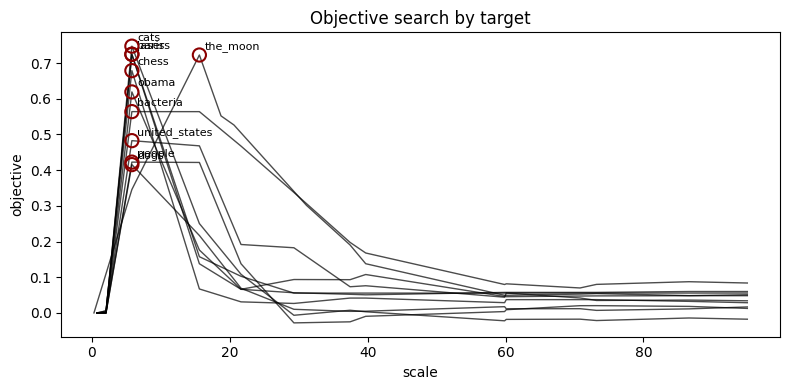

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

for target in objective_targets:
    trials_df = objective_trials[target].sort_values("params_scale")
    ax.plot(
        trials_df["params_scale"],
        trials_df["user_attrs_objective"],
        color="black",
        linewidth=1,
        alpha=0.7,
    )

    best_idx = trials_df["user_attrs_objective"].idxmax()
    best_row = trials_df.loc[best_idx]
    ax.scatter(
        best_row["params_scale"],
        best_row["user_attrs_objective"],
        facecolors="none",
        edgecolors="darkred",
        s=90,
        linewidths=1.5,
        zorder=3,
    )
    ax.annotate(
        target,
        (best_row["params_scale"], best_row["user_attrs_objective"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("scale")
ax.set_ylabel("objective")
ax.set_title("Objective search by target")
plt.tight_layout()
plt.show()

# Run QA Benchmark

In [24]:
objective_config = load_best_scales(
    OBJECTIVE_RESULTS_PATH,
    fallback_df=best_scales_df if "best_scales_df" in globals() else None,
    )

df_eval = sample_per_concept(df_test, n_per_concept=25)
run_specs = make_run_specs(objective_config)
QA_RESULTS_PATH = STORE / "qa_runs.csv"
QA_SCORED_PATH = STORE / "qa_runs_scored.csv"
QA_PPL_PATH = STORE / "qa_runs_scored_ppl.csv"

def steer_factory_for(target):
    return gated_steer_factory(
        v_detect[target],
        v_forget,
        thresholds[target],
        llm.device,
    )

In [25]:
qa_runs = run_qa_benchmark(
    llm=llm,
    df=df_eval,
    system_prompt=QA_SYSTEM,
    chat_cls=Chat,
    run_specs=run_specs,
    steer_factory_fn=steer_factory_for,
    csv_path=QA_RESULTS_PATH,
    generation_kwargs={"max_new_tokens": 128, "do_sample": False, "temperature": 1.0},
    trim_output_fn=trim_to_last_assistant,
    batch_size=128,
    )

qa_runs

QA benchmark runs:   0%|          | 0/20 [00:00<?, ?it/s]

,concept,target,question,correct_answer,scale,source_layer,target_layer,label,model_output
0,bacteria,cats,Name a free-living nitrogen-fixing bacterium i...,Azotobacter,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Azotobacter vinelandii is a free-living nitrog...
1,bacteria,cats,What is the dormant stage produced by sporulat...,endospore,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,The dormant stage produced by sporulation in b...
2,bacteria,cats,What term designates the bacterial chemotaxis ...,MCPs,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Methyl-accepting chemotaxis proteins (MCPs).
3,bacteria,cats,"During bacterial binary fission, which genetic...",Chromosome.,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,The circular bacterial chromosome is replicate...
4,bacteria,cats,What gram-stain result does Salmonella have?,Gram-negative,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Salmonella is a Gram-negative bacterium.
...,...,...,...,...,...,...,...,...,...
4995,united_states,dogs,Which US state leads peanut production?,Georgia,5.808361,"[15, 18, 21, 24]","[15, 18, 21, 24]",steered,Georgia leads peanut production in the United ...
4996,united_states,dogs,Which United States bridge connects Manhattan ...,Brooklyn Bridge,5.808361,"[15, 18, 21, 24]","[15, 18, 21, 24]",steered,The Brooklyn Bridge connects Manhattan and Bro...
4997,united_states,dogs,"In the United States, which national park has ...",Yellowstone National Park,5.808361,"[15, 18, 21, 24]","[15, 18, 21, 24]",steered,Yellowstone National Park.
4998,united_states,dogs,Which U.S. river runs through New York City an...,Hudson River,5.808361,"[15, 18, 21, 24]","[15, 18, 21, 24]",steered,The Hudson River runs through New York City an...


In [26]:
from evaluation import add_bertscore_columns

qa_runs = load_or_empty_results(QA_RESULTS_PATH, text_columns=["model_output"])
qa_runs["model_output"] = qa_runs["model_output"].apply(sanitize_generated_text)
qa_scored = add_bertscore_columns(qa_runs)
qa_scored = add_idk_ratio_column(qa_scored)
qa_scored.to_csv(QA_SCORED_PATH, index=False)

qa_scored

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


  0%|          | 0/14 [00:00<?, ?it/s]

computing greedy matching.


...

  0%|          | 0/10 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/79 [00:00<?, ?it/s]

done in 0.56 seconds, 8861.11 sentences/sec


,concept,target,question,correct_answer,scale,source_layer,target_layer,label,model_output,bert_sim_correct,bert_sim_idk,answer_score_gap,idk_ratio
0,bacteria,cats,Name a free-living nitrogen-fixing bacterium i...,Azotobacter,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Azotobacter vinelandii is a free-living nitrog...,0.882908,0.815722,0.067186,0.0
1,bacteria,cats,What is the dormant stage produced by sporulat...,endospore,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,The dormant stage produced by sporulation in b...,0.844811,0.845389,-0.000578,0.0
2,bacteria,cats,What term designates the bacterial chemotaxis ...,MCPs,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Methyl-accepting chemotaxis proteins (MCPs).,0.859143,0.817451,0.041692,0.0
3,bacteria,cats,"During bacterial binary fission, which genetic...",Chromosome.,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,The circular bacterial chromosome is replicate...,0.879711,0.854664,0.025047,0.0
4,bacteria,cats,What gram-stain result does Salmonella have?,Gram-negative,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Salmonella is a Gram-negative bacterium.,0.849024,0.829441,0.019582,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,united_states,dogs,Which US state leads peanut production?,Georgia,5.808361,"[15, 18, 21, 24]","[15, 18, 21, 24]",steered,Georgia leads peanut production in the United ...,0.894031,0.864110,0.029920,0.0
4996,united_states,dogs,Which United States bridge connects Manhattan ...,Brooklyn Bridge,5.808361,"[15, 18, 21, 24]","[15, 18, 21, 24]",steered,The Brooklyn Bridge connects Manhattan and Bro...,0.917896,0.844633,0.073262,0.0
4997,united_states,dogs,"In the United States, which national park has ...",Yellowstone National Park,5.808361,"[15, 18, 21, 24]","[15, 18, 21, 24]",steered,Yellowstone National Park.,0.992711,0.853992,0.138719,0.0
4998,united_states,dogs,Which U.S. river runs through New York City an...,Hudson River,5.808361,"[15, 18, 21, 24]","[15, 18, 21, 24]",steered,The Hudson River runs through New York City an...,0.880381,0.840408,0.039973,0.0


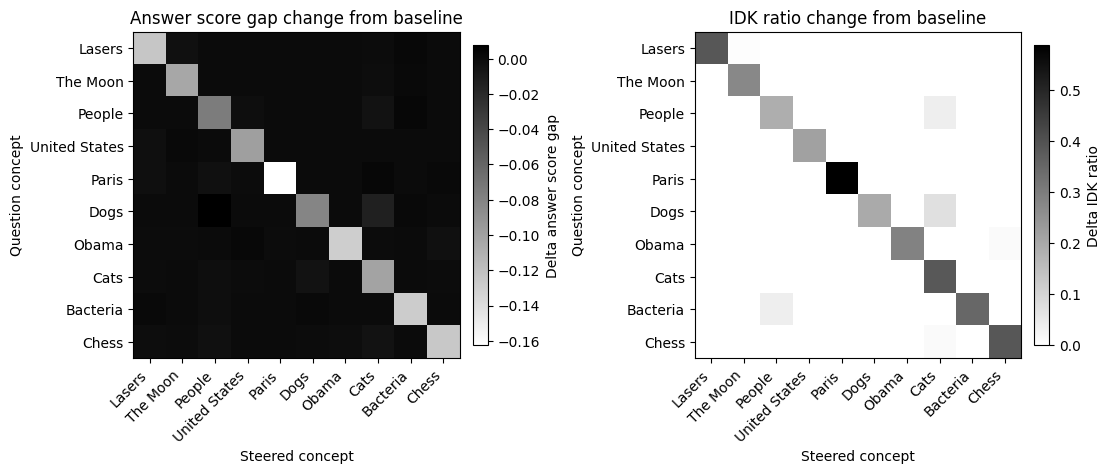

In [27]:
objective_layers = objective_config.iloc[0]["source_layer"]
baseline_df = qa_scored[qa_scored["label"] == "baseline"].copy()
steered_df = qa_scored[qa_scored["label"] == "steered"].copy()

plot_effect_heatmaps(
    steered_df,
    baseline_df,
    concepts,
    objective_layers,
    objective_layers,
    left_metric="answer_score_gap",
    right_metric="idk_ratio",
    left_title="Answer score gap change from baseline",
    right_title="IDK ratio change from baseline",
    left_label="Delta answer score gap",
    right_label="Delta IDK ratio",
    )

# QA Metric Plots

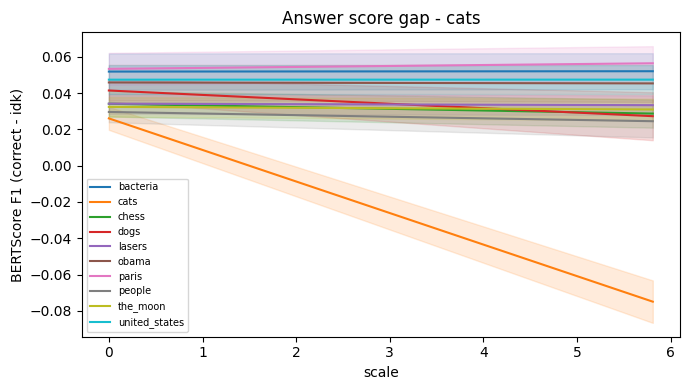

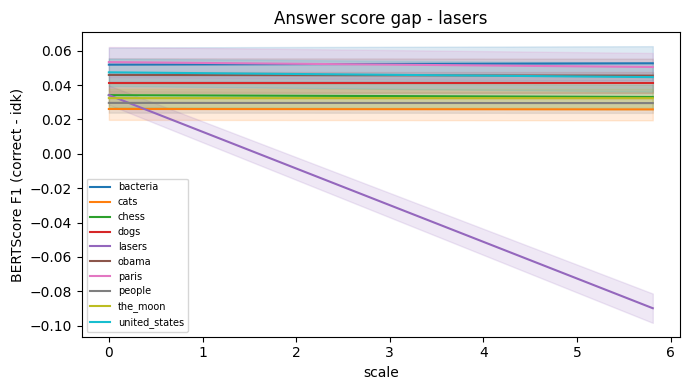

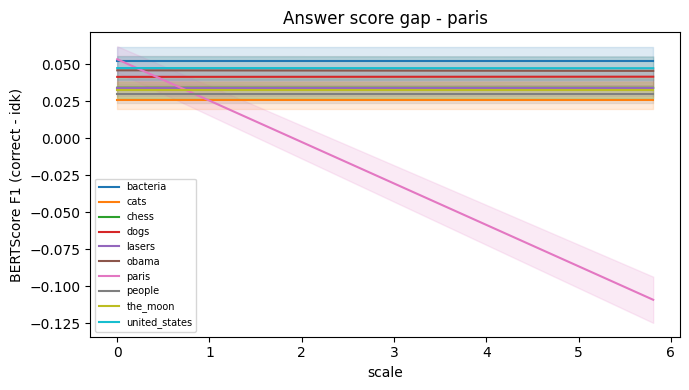

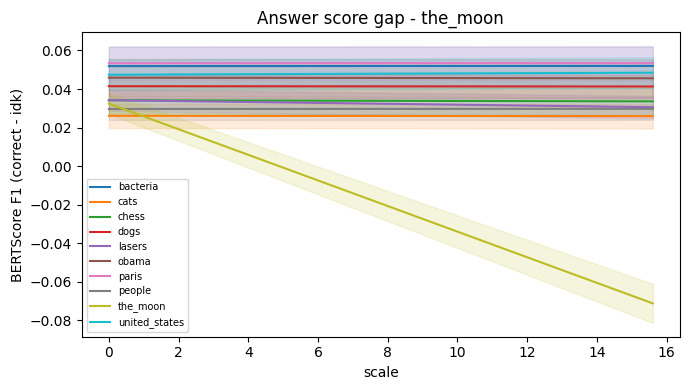

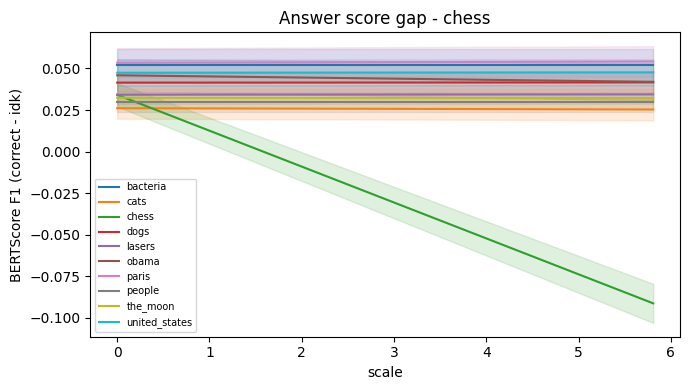

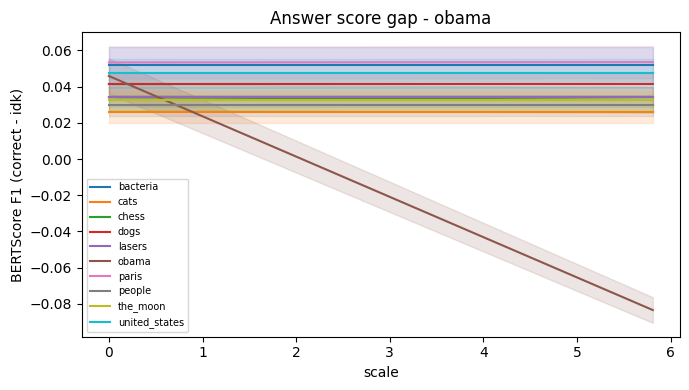

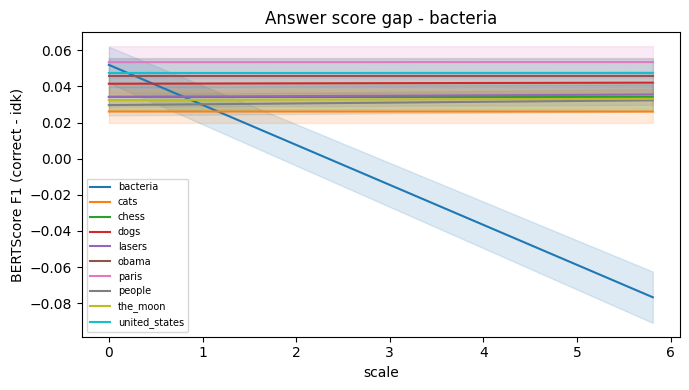

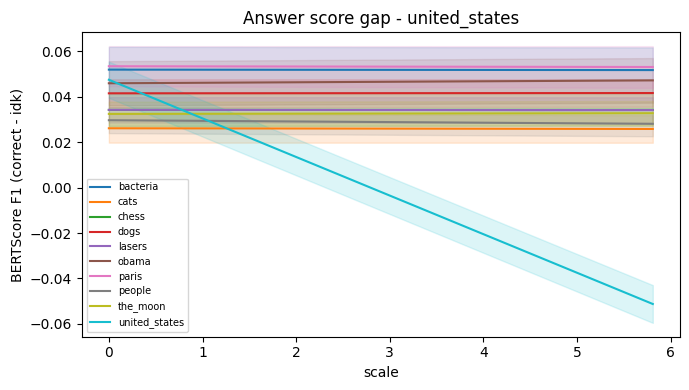

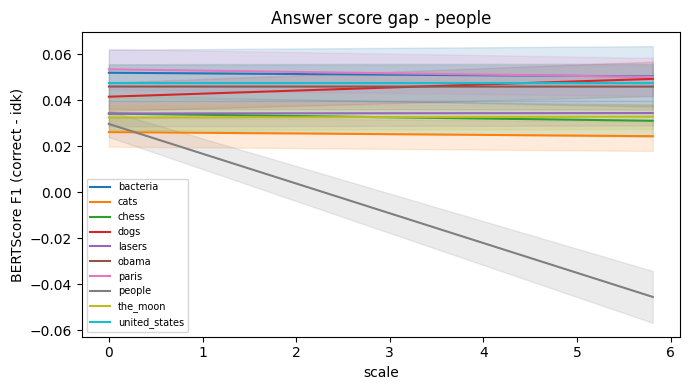

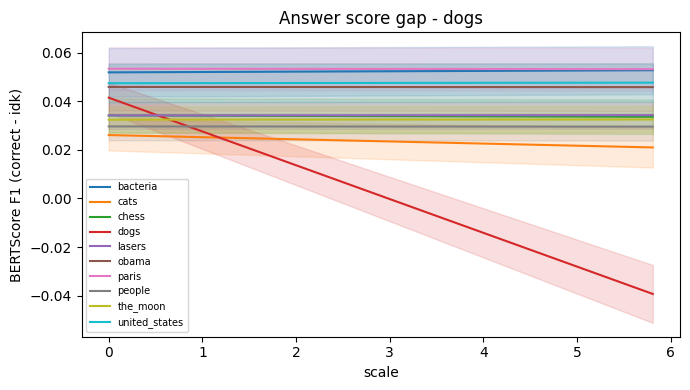

In [28]:
for target in qa_scored["target"].unique():
    plot_metric_by_scale(
        qa_scored[qa_scored["target"] == target],
        objective_layers,
        objective_layers,
        metric_col="answer_score_gap",
        label=f"Answer score gap - {target}",
        ylabel="BERTScore F1 (correct - idk)",
        show_std=True,
    )

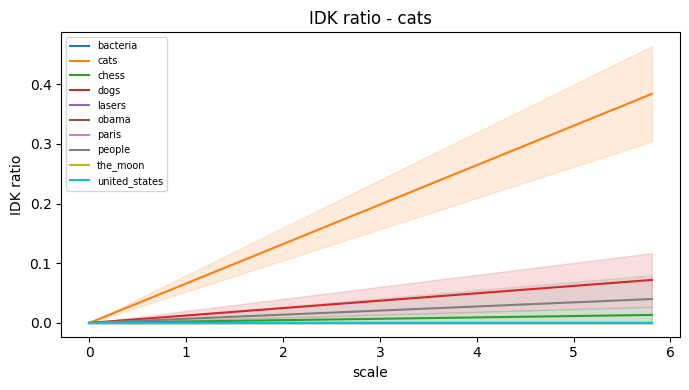

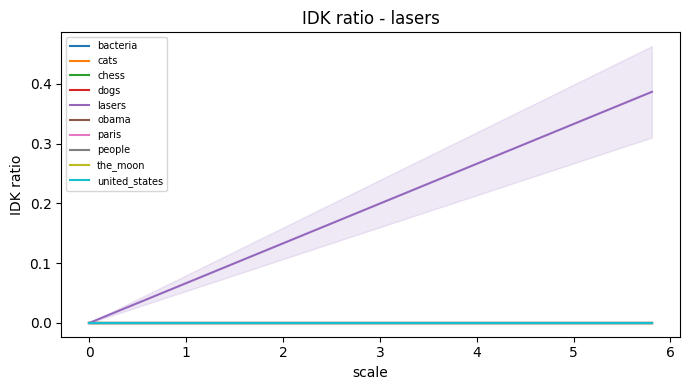

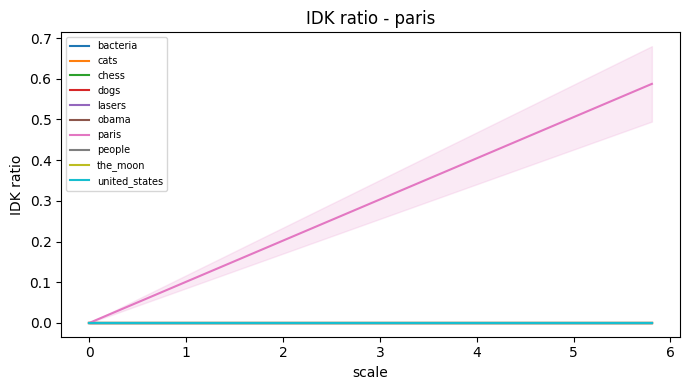

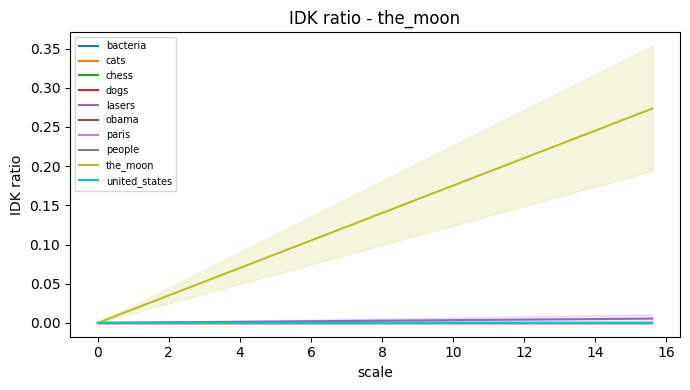

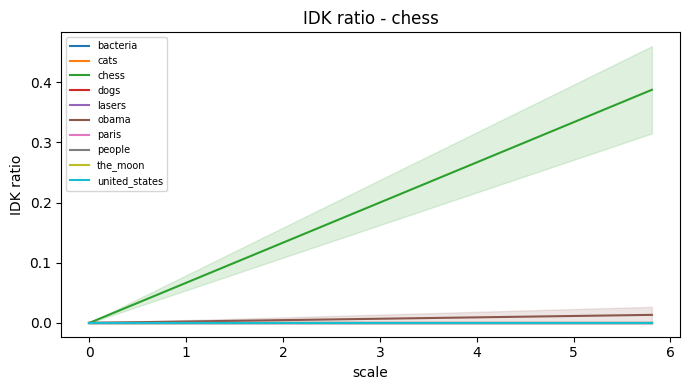

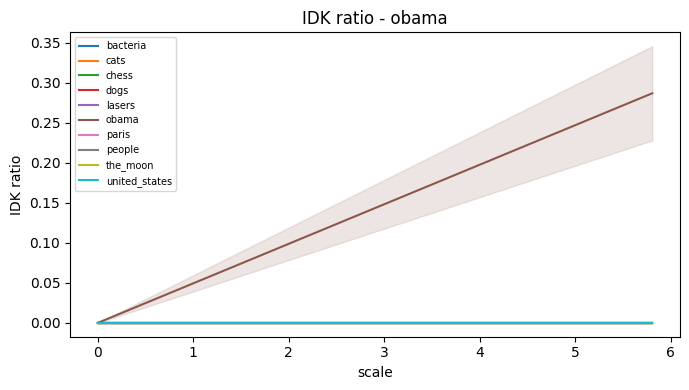

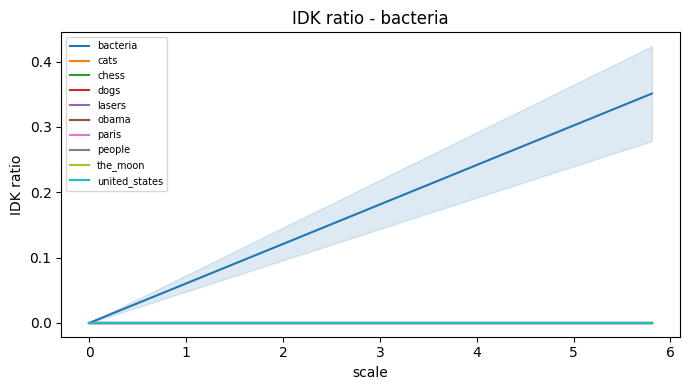

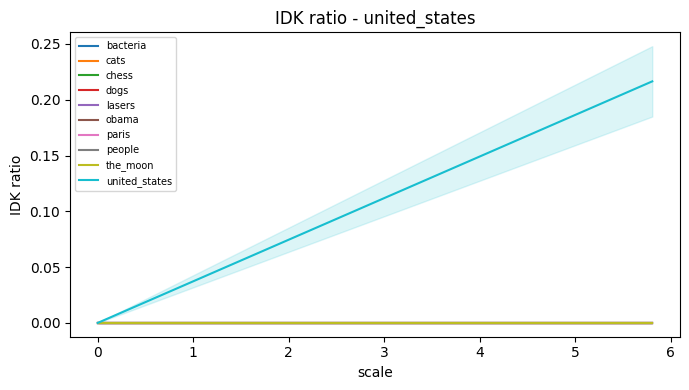

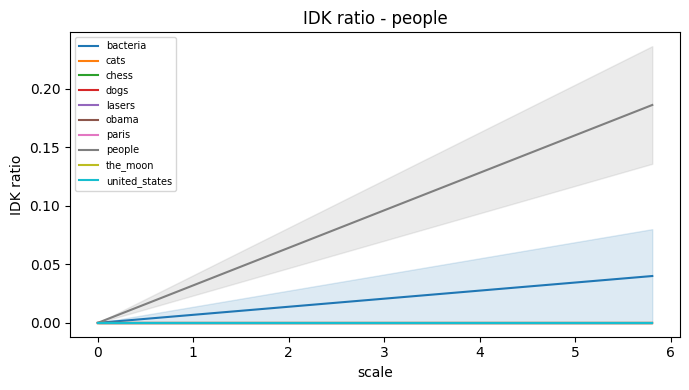

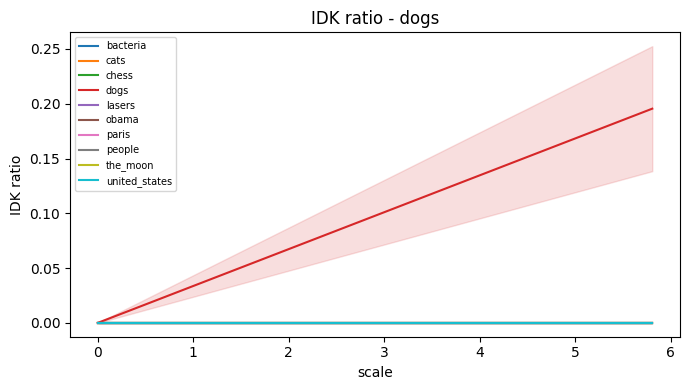

In [29]:
for target in qa_scored["target"].unique():
    plot_metric_by_scale(
        qa_scored[qa_scored["target"] == target],
        objective_layers,
        objective_layers,
        metric_col="idk_ratio",
        label=f"IDK ratio - {target}",
        ylabel="IDK ratio",
        show_std=True,
    )

In [30]:
qa_scored.head()

,concept,target,question,correct_answer,scale,source_layer,target_layer,label,model_output,bert_sim_correct,bert_sim_idk,answer_score_gap,idk_ratio
0,bacteria,cats,Name a free-living nitrogen-fixing bacterium i...,Azotobacter,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Azotobacter vinelandii is a free-living nitrog...,0.882908,0.815722,0.067186,0.0
1,bacteria,cats,What is the dormant stage produced by sporulat...,endospore,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,The dormant stage produced by sporulation in b...,0.844811,0.845389,-0.000578,0.0
2,bacteria,cats,What term designates the bacterial chemotaxis ...,MCPs,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Methyl-accepting chemotaxis proteins (MCPs).,0.859143,0.817451,0.041692,0.0
3,bacteria,cats,"During bacterial binary fission, which genetic...",Chromosome.,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,The circular bacterial chromosome is replicate...,0.879711,0.854664,0.025047,0.0
4,bacteria,cats,What gram-stain result does Salmonella have?,Gram-negative,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Salmonella is a Gram-negative bacterium.,0.849024,0.829441,0.019582,0.0


In [31]:
from evaluation import add_perplexity_column, load_perplexity_model

tokenizer, ppl_model = load_perplexity_model()
qa_ppl = add_perplexity_column(qa_scored, tokenizer, ppl_model)
qa_ppl.to_csv(QA_PPL_PATH, index=False)

qa_ppl

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


,concept,target,question,correct_answer,scale,source_layer,target_layer,label,model_output,bert_sim_correct,bert_sim_idk,answer_score_gap,idk_ratio,perplexity
0,bacteria,cats,Name a free-living nitrogen-fixing bacterium i...,Azotobacter,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Azotobacter vinelandii is a free-living nitrog...,0.882908,0.815722,0.067186,0.0,28.871052
1,bacteria,cats,What is the dormant stage produced by sporulat...,endospore,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,The dormant stage produced by sporulation in b...,0.844811,0.845389,-0.000578,0.0,230.336853
2,bacteria,cats,What term designates the bacterial chemotaxis ...,MCPs,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Methyl-accepting chemotaxis proteins (MCPs).,0.859143,0.817451,0.041692,0.0,139.974823
3,bacteria,cats,"During bacterial binary fission, which genetic...",Chromosome.,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,The circular bacterial chromosome is replicate...,0.879711,0.854664,0.025047,0.0,2491.152832
4,bacteria,cats,What gram-stain result does Salmonella have?,Gram-negative,0.000000,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Salmonella is a Gram-negative bacterium.,0.849024,0.829441,0.019582,0.0,16.664419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,united_states,dogs,Which US state leads peanut production?,Georgia,5.808361,"[15, 18, 21, 24]","[15, 18, 21, 24]",steered,Georgia leads peanut production in the United ...,0.894031,0.864110,0.029920,0.0,112.607033
4996,united_states,dogs,Which United States bridge connects Manhattan ...,Brooklyn Bridge,5.808361,"[15, 18, 21, 24]","[15, 18, 21, 24]",steered,The Brooklyn Bridge connects Manhattan and Bro...,0.917896,0.844633,0.073262,0.0,60.526497
4997,united_states,dogs,"In the United States, which national park has ...",Yellowstone National Park,5.808361,"[15, 18, 21, 24]","[15, 18, 21, 24]",steered,Yellowstone National Park.,0.992711,0.853992,0.138719,0.0,122.930984
4998,united_states,dogs,Which U.S. river runs through New York City an...,Hudson River,5.808361,"[15, 18, 21, 24]","[15, 18, 21, 24]",steered,The Hudson River runs through New York City an...,0.880381,0.840408,0.039973,0.0,15.595487


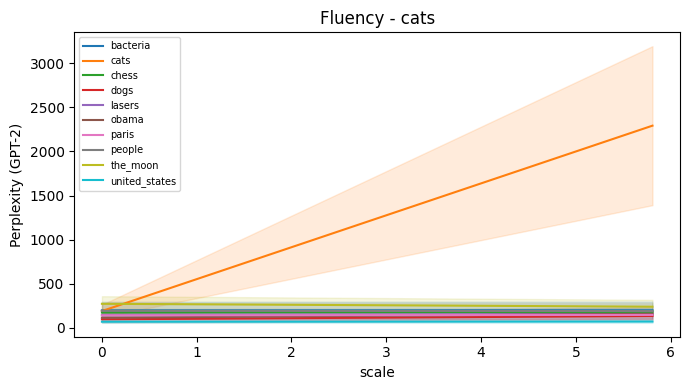

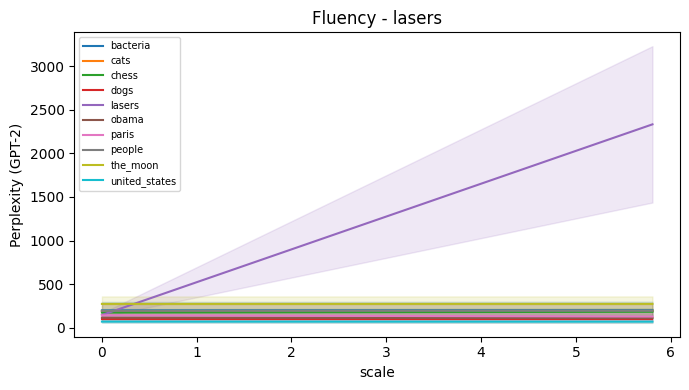

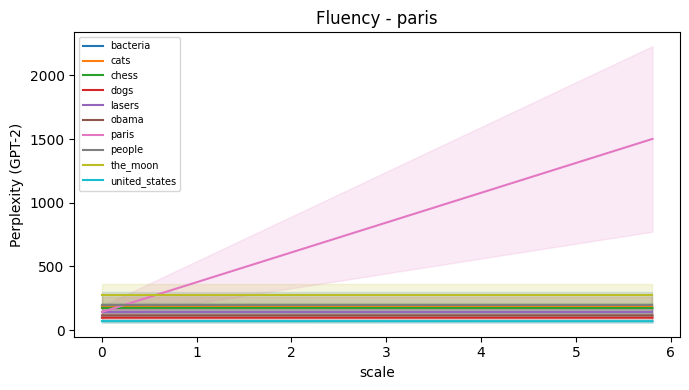

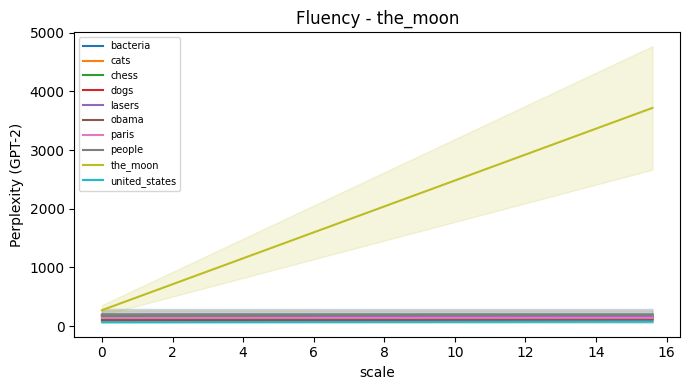

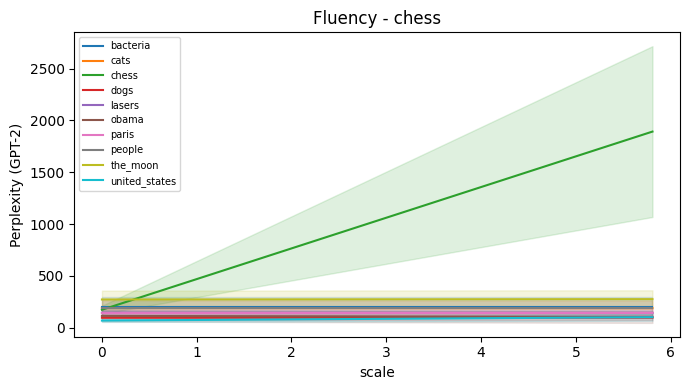

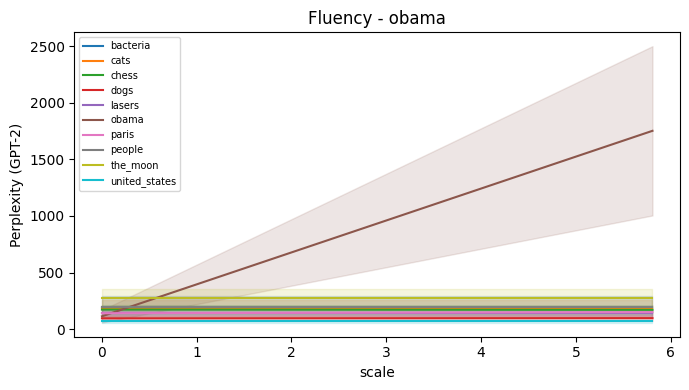

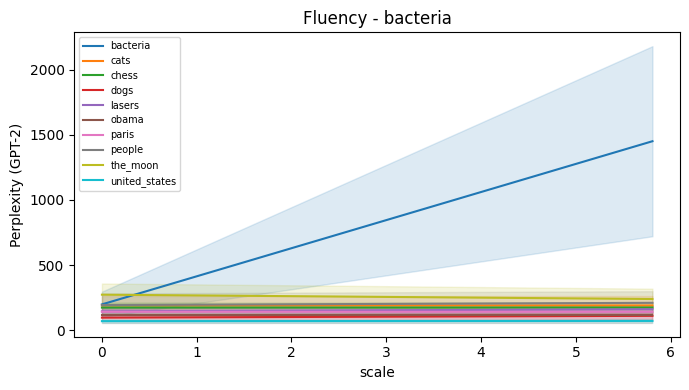

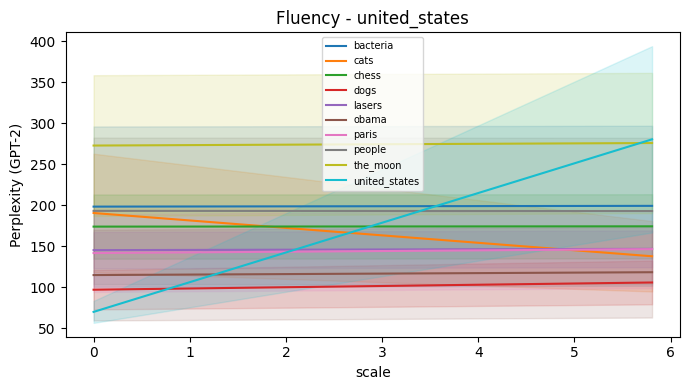

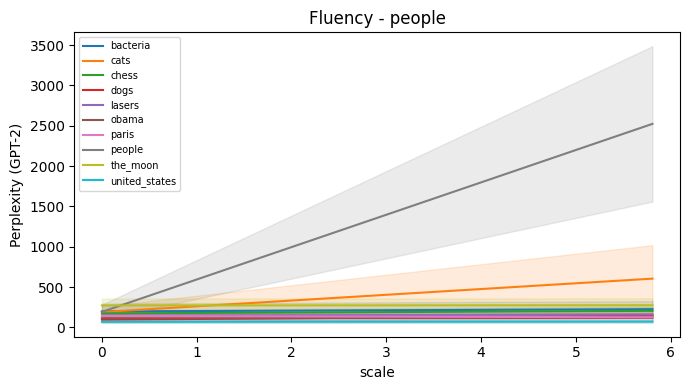

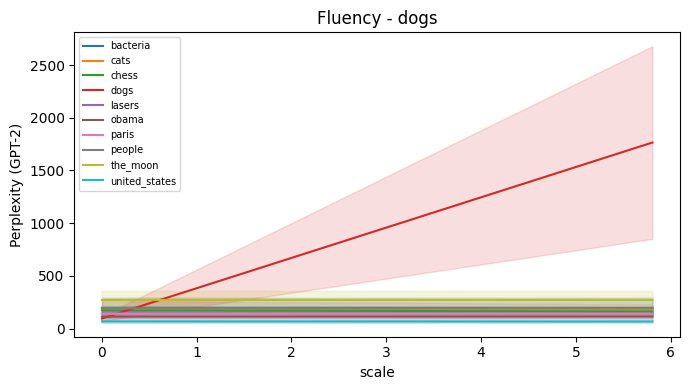

In [32]:
for target in qa_ppl["target"].unique():
    plot_metric_by_scale(
        qa_ppl[qa_ppl["target"] == target],
        objective_layers,
        objective_layers,
        metric_col="perplexity",
        label=f"Fluency - {target}",
        ylabel="Perplexity (GPT-2)",
        show_std=True,
    )